<a href="https://colab.research.google.com/github/kartikpatil124/customer_support_ticket_resolution_satisfaction/blob/main/Copy_of_Support_ticket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
file_path = r"/content/customer_support_ticket_resolution_satisfaction.csv"

df = pd.read_csv(file_path)

In [ ]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2800, 10)

First 5 Rows:
   ticket_id created_date issue_category priority  first_response_minutes  \
0          1   2024-08-24       Delivery      Low                     114   
1          2   2024-05-07        Account   Medium                      13   
2          3   2024-08-03        Account   Urgent                     225   
3          4   2024-03-09       Delivery     High                     121   
4          5   2024-04-30      Technical   Urgent                     162   

   resolution_time_hours  agent_experience_years reopened channel  \
0                     62                     6.0      Yes    Chat   
1                     67                     5.2      Yes   Email   
2                     18                     6.2       No   Phone   
3                     23                     7.0       No   Email   
4                     49                     0.9      Yes   Email   

  customer_satisfaction  
0                   Low  
1                Medium  
2  

In [ ]:
print(df.isnull().sum())

ticket_id                 0
created_date              0
issue_category            0
priority                  0
first_response_minutes    0
resolution_time_hours     0
agent_experience_years    0
reopened                  0
channel                   0
customer_satisfaction     0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
print("Duplicate Ticket IDs:", df["ticket_id"].duplicated().sum())

Duplicate Ticket IDs: 0


In [ ]:
df["created_date"] = pd.to_datetime(df["created_date"])

In [ ]:
df["Resolution_Band"] = np.select(
    [
        df["resolution_time_hours"] <= 24,
        df["resolution_time_hours"] <= 48
    ],
    [
        "Fast",
        "Moderate"
    ],
    default="Slow"
)

In [ ]:
df["Resolution_Band"] = np.select(
    [
        df["resolution_time_hours"] <= 24,
        df["resolution_time_hours"] <= 48
    ],
    [
        "Fast",
        "Moderate"
    ],
    default="Slow"
)

In [ ]:
df["Response_Band"] = np.select(
    [
        df["first_response_minutes"] <= 30,
        df["first_response_minutes"] <= 120
    ],
    [
        "Fast",
        "Moderate"
    ],
    default="Slow"
)

print(df["Response_Band"])

0       Moderate
1           Fast
2           Slow
3           Slow
4           Slow
          ...   
2795        Slow
2796        Slow
2797        Fast
2798        Slow
2799    Moderate
Name: Response_Band, Length: 2800, dtype: object


In [ ]:
print(df.shape)
print(df.head())

(2800, 12)
   ticket_id created_date issue_category priority  first_response_minutes  \
0          1   2024-08-24       Delivery      Low                     114   
1          2   2024-05-07        Account   Medium                      13   
2          3   2024-08-03        Account   Urgent                     225   
3          4   2024-03-09       Delivery     High                     121   
4          5   2024-04-30      Technical   Urgent                     162   

   resolution_time_hours  agent_experience_years reopened channel  \
0                     62                     6.0      Yes    Chat   
1                     67                     5.2      Yes   Email   
2                     18                     6.2       No   Phone   
3                     23                     7.0       No   Email   
4                     49                     0.9      Yes   Email   

  customer_satisfaction Resolution_Band Response_Band  
0                   Low            Slow      Moderate  

In [ ]:
issue_analysis = (
    df.groupby("issue_category")
      .agg(
          total_tickets=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          avg_first_response_minutes=("first_response_minutes", "mean"),

      )
      .round(2)
      .sort_values("avg_resolution_hours", ascending=False)
)

print(issue_analysis)

                total_tickets  avg_resolution_hours  \
issue_category                                        
Account                   582                 37.66   
Other                     553                 37.07   
Technical                 536                 36.63   
Delivery                  559                 36.39   
Billing                   570                 35.05   

                avg_first_response_minutes  
issue_category                              
Account                             121.85  
Other                               123.14  
Technical                           122.21  
Delivery                            123.75  
Billing                             124.14  


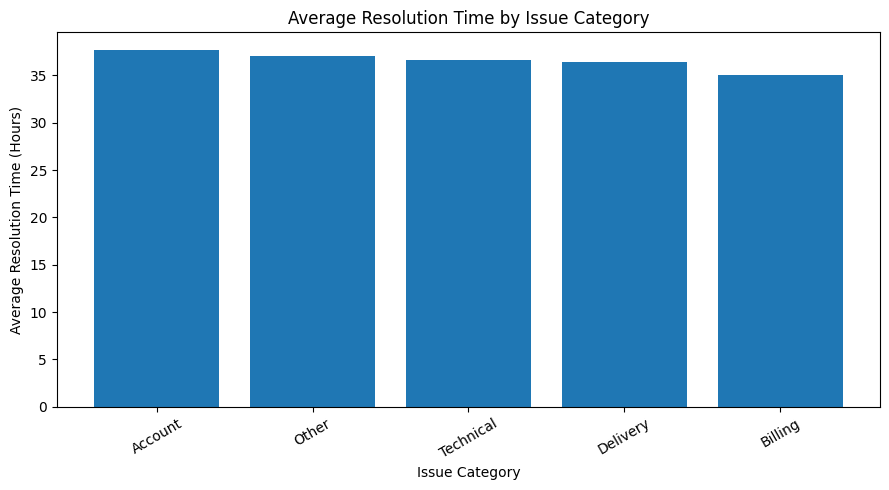

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    issue_analysis.index,
    issue_analysis["avg_resolution_hours"]
)

plt.title("Average Resolution Time by Issue Category")
plt.xlabel("Issue Category")
plt.ylabel("Average Resolution Time (Hours)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()